<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"></ul></div>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [39]:
df = pd.read_csv('Movies.csv', delimiter=',')

In [40]:
df = df.iloc[:, 1:]

In [41]:
df.head()

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),Genre,Movie Runtime,License
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,"December 16, 2015",936662225,1132859475,2069521700,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,"April 24, 2019",858373000,1939128328,2797501328,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,"December 16, 2009",760507625,2086738578,2847246203,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13
3,Black Panther (2018),"T'Challa, heir to the hidden but advanced king...",Walt Disney Studios Motion Pictures,NaN,700426566,647171407,1347597973,"['Action', 'Adventure', 'Sci-Fi']",2 hr 14 min,NaN
4,Avengers: Infinity War (2018),The Avengers and their allies must be willing ...,Walt Disney Studios Motion Pictures,NaN,678815482,1369544272,2048359754,"['Action', 'Adventure', 'Sci-Fi']",2 hr 29 min,NaN


In [42]:
df.shape

(918, 10)

In [43]:
df.dtypes

Title                         object
Movie Info                    object
Distributor                   object
Release Date                  object
Domestic Sales (in $)          int64
International Sales (in $)     int64
World Sales (in $)             int64
Genre                         object
Movie Runtime                 object
License                       object
dtype: object

In [44]:
df.describe()

,Domestic Sales (in $),International Sales (in $),World Sales (in $)
count,9.180000e+02,9.180000e+02,9.180000e+02
mean,1.677469e+08,2.301434e+08,3.968668e+08
std,1.040360e+08,2.176011e+08,3.082629e+08
min,8.036084e+07,2.600000e+02,8.160000e+07
25%,1.016071e+08,8.845620e+07,2.005564e+08
50%,1.321351e+08,1.638819e+08,3.019416e+08
75%,1.913905e+08,2.885577e+08,4.750718e+08
max,9.366622e+08,2.086739e+09,2.847246e+09


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Title                       918 non-null    object
 1   Movie Info                  918 non-null    object
 2   Distributor                 918 non-null    object
 3   Release Date                800 non-null    object
 4   Domestic Sales (in $)       918 non-null    int64 
 5   International Sales (in $)  918 non-null    int64 
 6   World Sales (in $)          918 non-null    int64 
 7   Genre                       918 non-null    object
 8   Movie Runtime               918 non-null    object
 9   License                     744 non-null    object
dtypes: int64(3), object(7)
memory usage: 71.8+ KB


In [46]:
df["World Sales (in $)"].min()

81600000

In [47]:
df["World Sales (in $)"].max()

2847246203

In [48]:
df["Distributor"].unique()

array(['Walt Disney Studios Motion Pictures', 'Twentieth Century Fox',
       'Sony Pictures Entertainment (SPE)', 'Paramount Pictures',
       'Universal Pictures', 'Warner Bros.', 'DreamWorks Distribution',
       'Lionsgate', 'DreamWorks', 'New Line Cinema', 'Newmarket Films',
       'Summit Entertainment', 'Columbia Pictures', 'IFC Films',
       'TriStar Pictures', 'Orion Pictures', 'Metro-Goldwyn-Mayer (MGM)',
       'Miramax', 'The Weinstein Company', 'Fox Searchlight Pictures',
       'Revolution Studios', 'Artisan Entertainment',
       'Sony Pictures Classics', 'United Artists', 'Screen Gems',
       'USA Films', '20th Century Studios', 'STX Entertainment',
       'Dimension Films', 'United Artists Releasing', 'FilmDistrict',
       'Focus Features', 'Relativity Media', 'Roadside Attractions'],
      dtype=object)

In [49]:
df["License"].value_counts()

License
PG-13    363
R        194
PG       173
G         14
Name: count, dtype: int64

🔹 **Задание 1. Первичный анализ данных**

1. Загрузите файл в датафрейм и выведите первые 5 строк (Подсказка: найти в документации pandas, как читать csv файл, выставить разделителем запятую).
2. Первый столбец - индекс, который перезаписался как отдельный столбец: удалите его
3. Определите и выведите:

* количество строк и столбцов

* типы данных

* общую информацию по таблице и краткую статистику по числовым столбцам

* минимальное и максимальное значение по мировым сборам

* уникальные жанры

* количество фильмов по каждому рейтингу

🔹 **Задание 2. Обработка пропусков и создание новых признаков**

1. Проверьте, в каких столбцах есть пропуски.
2. Замените пропуски в столбце с рейтингом на самое частотное значение (Подсказка: заменить на mode()[0]).
3. Удалите все строки с пропусками в дате релиза.
3. Добавьте новый столбец: доля домашних сборов относительно мировых.

In [50]:
df.isna().sum()

Title                           0
Movie Info                      0
Distributor                     0
Release Date                  118
Domestic Sales (in $)           0
International Sales (in $)      0
World Sales (in $)              0
Genre                           0
Movie Runtime                   0
License                       174
dtype: int64

In [51]:
most_frequent_license = df['License'].mode()[0]
print(most_frequent_license)

PG-13


In [52]:
df["License"] = df["License"].fillna(most_frequent_license)

In [53]:
df = df.dropna(subset=['Release Date'])

In [54]:
df['Domestic_ratio'] = df['Domestic Sales (in $)'] / df['Domestic Sales (in $)']

🔹 **Задание 3. Работа с датами**

1. Преобразуйте столбец Release Date в тип datetime (Подсказка: найти в документации pandas, как вызывать функцию to_datetime).
2. Добавьте новый столбец Year, извлекая из даты только год (Подсказка: найти в документации pandas, как вызывать функцию dt.year).

In [55]:
df['Release Date'] = pd.to_datetime(df['Release Date'])
df.head()

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),Genre,Movie Runtime,License,Domestic_ratio
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,2015-12-16,936662225,1132859475,2069521700,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13,1.0
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,2019-04-24,858373000,1939128328,2797501328,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13,1.0
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,2009-12-16,760507625,2086738578,2847246203,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13,1.0
6,Titanic (1997),A seventeen-year-old aristocrat falls in love ...,Paramount Pictures,1997-12-19,659363944,1542283320,2201647264,"['Drama', 'Romance']",3 hr 14 min,PG-13,1.0
7,Jurassic World (2015),"A new theme park, built on the original site o...",Universal Pictures,2015-06-10,652385625,1018130819,1670516444,"['Action', 'Adventure', 'Sci-Fi']",2 hr 4 min,PG-13,1.0


In [56]:
df['Year'] = df['Release Date'].dt.year
df.head()

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),Genre,Movie Runtime,License,Domestic_ratio,Year
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,2015-12-16,936662225,1132859475,2069521700,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13,1.0,2015
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,2019-04-24,858373000,1939128328,2797501328,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13,1.0,2019
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,2009-12-16,760507625,2086738578,2847246203,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13,1.0,2009
6,Titanic (1997),A seventeen-year-old aristocrat falls in love ...,Paramount Pictures,1997-12-19,659363944,1542283320,2201647264,"['Drama', 'Romance']",3 hr 14 min,PG-13,1.0,1997
7,Jurassic World (2015),"A new theme park, built on the original site o...",Universal Pictures,2015-06-10,652385625,1018130819,1670516444,"['Action', 'Adventure', 'Sci-Fi']",2 hr 4 min,PG-13,1.0,2015


🔹 **Задание 4. Фильтрация данных и срезы**

1. Найдите и выведите фильмы с 10 по 20 строку:

* с домашними сборами больше 70 миллионов (только столбцы с названиями фильмов и домашними сборами)

* со мстителями (в названии есть "Avengers") (только столбцы с названиями фильмов и описанием)

* 20-ого века и студии Paramount Pictures (только столбцы с названиями фильмов, годом и студией)

2. Отсортируйте и пересохраните таблицу в порядке убывания мировых сборов.

In [57]:
df[df["Domestic Sales (in $)"] > 70000000]

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),Genre,Movie Runtime,License,Domestic_ratio,Year
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,2015-12-16,936662225,1132859475,2069521700,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13,1.0,2015
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,2019-04-24,858373000,1939128328,2797501328,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13,1.0,2019
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,2009-12-16,760507625,2086738578,2847246203,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13,1.0,2009
6,Titanic (1997),A seventeen-year-old aristocrat falls in love ...,Paramount Pictures,1997-12-19,659363944,1542283320,2201647264,"['Drama', 'Romance']",3 hr 14 min,PG-13,1.0,1997
7,Jurassic World (2015),"A new theme park, built on the original site o...",Universal Pictures,2015-06-10,652385625,1018130819,1670516444,"['Action', 'Adventure', 'Sci-Fi']",2 hr 4 min,PG-13,1.0,2015
...,...,...,...,...,...,...,...,...,...,...,...,...
913,The Notebook (2004),A poor yet passionate young man falls in love ...,New Line Cinema,2004-06-25,81001787,36813370,117815157,"['Drama', 'Romance']",2 hr 3 min,PG-13,1.0,2004
914,Jimmy Neutron: Boy Genius (2001),An eight-year-old boy genius and his friends m...,Paramount Pictures,2001-12-21,80936232,22056304,102992536,"['Action', 'Adventure', 'Animation', 'Comedy',...",1 hr 22 min,PG-13,1.0,2001
915,Eat Pray Love (2010),A married woman realizes how unhappy her marri...,Sony Pictures Entertainment (SPE),2010-08-13,80574010,124020006,204594016,"['Biography', 'Drama', 'Romance']",2 hr 13 min,PG-13,1.0,2010
916,The Texas Chainsaw Massacre (2003),After picking up a traumatized young hitchhike...,New Line Cinema,2003-10-17,80571655,26792250,107363905,"['Crime', 'Horror']",1 hr 38 min,R,1.0,2003


In [58]:
df.sort_values(["World Sales (in $)"], ascending=False).head()

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),Genre,Movie Runtime,License,Domestic_ratio,Year
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,2009-12-16,760507625,2086738578,2847246203,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13,1.0,2009
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,2019-04-24,858373000,1939128328,2797501328,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13,1.0,2019
6,Titanic (1997),A seventeen-year-old aristocrat falls in love ...,Paramount Pictures,1997-12-19,659363944,1542283320,2201647264,"['Drama', 'Romance']",3 hr 14 min,PG-13,1.0,1997
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,2015-12-16,936662225,1132859475,2069521700,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13,1.0,2015
7,Jurassic World (2015),"A new theme park, built on the original site o...",Universal Pictures,2015-06-10,652385625,1018130819,1670516444,"['Action', 'Adventure', 'Sci-Fi']",2 hr 4 min,PG-13,1.0,2015


In [59]:
df[df["Title"].str.contains("Avengers")]

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),Genre,Movie Runtime,License,Domestic_ratio,Year
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,2019-04-24,858373000,1939128328,2797501328,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13,1.0,2019
8,The Avengers (2012),Earth's mightiest heroes must come together an...,Walt Disney Studios Motion Pictures,2012-04-25,623357910,895457605,1518815515,"['Action', 'Adventure', 'Sci-Fi']",2 hr 23 min,PG-13,1.0,2012
20,Avengers: Age of Ultron (2015),When Tony Stark and Bruce Banner try to jump-s...,Walt Disney Studios Motion Pictures,2015-04-22,459005868,943803672,1402809540,"['Action', 'Adventure', 'Sci-Fi']",2 hr 21 min,PG-13,1.0,2015


In [60]:
df.loc[(df["Year"] < 2000) & (df["Distributor"] == "Paramount Pictures"), ["Title", "Year", "Distributor"]]

,Title,Year,Distributor
6,Titanic (1997),1997,Paramount Pictures
67,Forrest Gump (1994),1994,Paramount Pictures
133,Indiana Jones and the Raiders of the Lost Ark ...,1981,Paramount Pictures
174,Ghost (1990),1990,Paramount Pictures
221,Indiana Jones and the Last Crusade (1989),1989,Paramount Pictures
232,Grease (1978),1978,Paramount Pictures
258,Mission: Impossible (1996),1996,Paramount Pictures
263,Indiana Jones and the Temple of Doom (1984),1984,Paramount Pictures
363,Runaway Bride (1999),1999,Paramount Pictures
441,The Godfather (1972),1972,Paramount Pictures


🔹 **Задание 5. Группировка, агрегация и визуализация**

1. Создайте таблицу с группировкой: сколько фильмов вышло в каждом году.
2. Постройте график по этим данным с:
* подписями осей
* названием графика
* сеткой

3. Создайте таблицу с двойной группировкой: сколько суммарно общемировых сборов собрала каждая студия, сколько фильмов каждая студия сняла.
4. Постройте сабплоты: две столбчатые диаграммы друг под другом по этим данным с:
* размером фигуры 12 * 12
* подписями осей
* названием графика
* цветовой палитрой
* повернутыми на 90 градусов лейблами на оси X
* перед выводом графика добавьте plt.tight_layot(), чтобы графики не накладывались друг на друга

In [61]:
how_many_movies = (
    df.groupby("Year")["Title"]
    .count()
).reset_index()
how_many_movies.rename(columns={"Title": "Number"}, inplace=True)

In [62]:
how_many_movies

,Year,Number
0,1972,1
1,1975,1
2,1977,1
3,1978,2
4,1979,2
5,1980,1
6,1981,2
7,1982,2
8,1983,2
9,1984,2


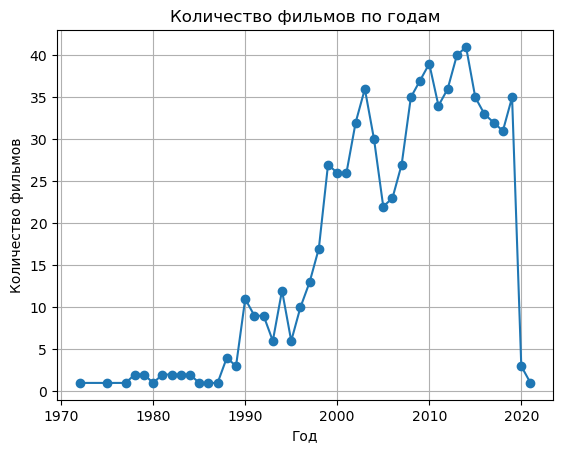

In [63]:

plt.figure()
plt.plot(how_many_movies["Year"],
         how_many_movies["Number"],
         marker="o")
plt.title("Количество фильмов по годам")
plt.xlabel("Год")
plt.ylabel("Количество фильмов")
plt.grid(True)
plt.show()

In [64]:
table = (
    df.groupby("Distributor")
    .agg(avg_sales=("International Sales (in $)", "sum"), numb=("Title", "count"))
    .reset_index()
)

In [65]:
table

,Distributor,avg_sales,numb
0,Artisan Entertainment,108100000,1
1,Columbia Pictures,595122247,6
2,Dimension Films,531129726,7
3,DreamWorks,6135580894,19
4,DreamWorks Distribution,2737597941,16
5,FilmDistrict,149677432,2
6,Focus Features,191960359,2
7,Fox Searchlight Pictures,548411398,3
8,IFC Films,127305836,1
9,Lionsgate,3820349662,16


ValueError: Could not interpret value `International Sales (in $)` for `y`. An entry with this name does not appear in `data`.

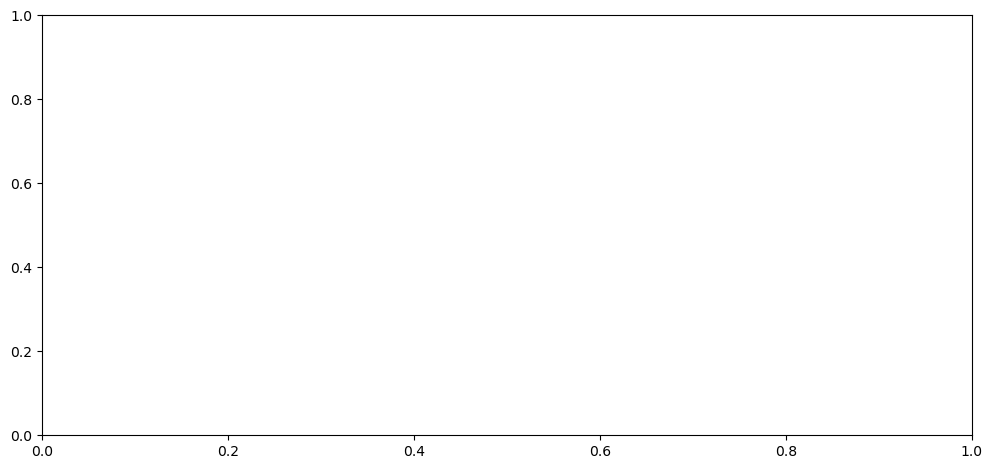

In [66]:
plt.figure(figsize=(12, 12))
plt.subplot(2, 1, 1)
sns.barplot(data=table, x="Distributor", y="International Sales (in $)", palette="Pinks_d")
plt.title("Суммарные общемировые сборы")

🔹 **Задание 6. Кастомные функции и применение apply()**

1. Напишите функцию movie_runtime_minutes, которая переведет длительность фильмов из текстового формата в минуты:
* как один из вариантов, можно найти оба числа, то есть часы и минуты, с помощью re.findall("[0-9]{1, }", x), не забыв импортировать библиотеку re
* сохранить это как список, затем умножить первое число (час) из списка на 60, прибавить второе число (минуты): не забыть учесть, что не во всех фильмах указаны минуты - значит, нужно прописать отдельные условия, если есть и часы, и минуты, или есть только часы
* не забыть, что элементы в списке - строковые, нужно перевести их в числа: условно будет int(numbers[0])*60 + ...
2. Примените функцию к таблице, создав новый столбец Movie Runtime Minutes.

In [ ]:
def movie_runtime_minutes(x):
    lst = re.findall("[0-9]{1,}", x['Movie Runtime'])
    if len(lst)>1:
        minutes = int(lst[0])*60 + int(lst[1])
    elif len(lst)==1:
        minutes = int(lst[0])
    else:
        minutes = 0
    return minutes
df["movie_runtime_minutes"] = df.apply(movie_runtime_minutes, axis=1)
df.head()

🔹 **Задание 7. Визуализация корреляций**

1. Выведите корреляционную матрицу по числовым признакам в таблице.
2. Постройте тепловую карту по этим данным с названием графика.
3. Напишите в отдельной ячейке markdown, есть ли взаимосвязь между продолжительностью фильма и его сборами?
4. Постройте диаграмму рассеяния между признаками, у которых наибольшая корреляция (Подсказка: в документации найдите matplotlib scatter, какие обязательные параметры туда нужно передать).
5. Сохраните итоговую таблицу в excel.

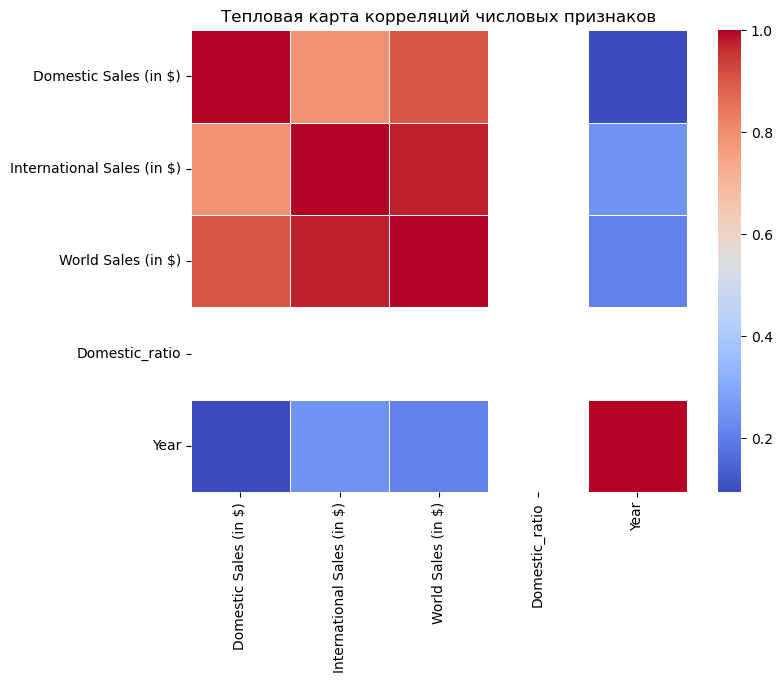

In [67]:
plt.figure
plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    linewidths=0.5,
)
plt.title("Тепловая карта корреляций числовых признаков", fontsize=12)

plt.show()

In [68]:
df.corr(numeric_only=True)

,Domestic Sales (in $),International Sales (in $),World Sales (in $),Domestic_ratio,Year
Domestic Sales (in $),1.000000,0.792538,0.901854,NaN,0.094280
International Sales (in $),0.792538,1.000000,0.977177,NaN,0.247533
World Sales (in $),0.901854,0.977177,1.000000,NaN,0.210808
Domestic_ratio,NaN,NaN,NaN,NaN,NaN
Year,0.094280,0.247533,0.210808,NaN,1.000000


In [ ]:
df.to_excel("Обработанные данные.xlsx", index=False)

